# 06 - Modelo em Dois Estágios (Two-Stage Pipeline)

## Motivação

Os modelos anteriores trataram classificação e regressão como problemas **independentes**:
- Notebook 03: "O voo vai atrasar?" (classificação)
- Notebook 05: "Quanto tempo vai atrasar?" (regressão, somente nos voos já atrasados)

O **modelo em dois estágios** combina os dois em um único pipeline:

```
Voo → [Stage 1: Classificador] → Vai atrasar?
                  ├── NÃO → Predição = 0 min
                  └── SIM → [Stage 2: Regressor] → Predição = X min
```

## Vantagens
- Realista: gera previsão de minutos para **qualquer voo** (não só os já atrasados)
- Interpretável: separa as duas perguntas distintas
- Melhor para uso prático (ex: sistema de alertas de aeroporto)

## Objetivos
- Treinar o pipeline dois estágios com split consistente
- Avaliar no conjunto de teste completo
- Comparar com baseline e com regressão direta

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor

import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Carregar Dados

In [2]:
df = pd.read_csv('../data/processed/flights_processed.csv')
print(f'Shape: {df.shape}')
print(f'Colunas disponíveis: {len(df.columns)}')

Shape: (5714008, 62)
Colunas disponíveis: 62


## 2. Preparar Features e Targets

O pipeline usa **dois targets**:
- `y_clf`: variável binária `DELAYED` → treinamento do Stage 1
- `y_reg`: variável contínua `ARRIVAL_DELAY` → avaliação do pipeline completo

In [3]:
# Features — mesmo conjunto do notebook 02/03/05 (18 features)
features = [
    # Temporal — encoding cíclico
    'MONTH_SIN', 'MONTH_COS',
    'DOW_SIN', 'DOW_COS',
    'HOUR_SIN', 'HOUR_COS',
    # Temporal — ordinal
    'DAY',
    # Operacional
    'AIRLINE_ENCODED', 'ORIGIN_ENCODED', 'DEST_ENCODED',
    # Características do voo
    'SCHEDULED_TIME', 'DISTANCE',
    # Variáveis derivadas
    'PERIOD_ENCODED', 'SEASON_ENCODED', 'IS_WEEKEND',
    # Features avançadas
    'IS_HOLIDAY', 'ROUTE_DELAY_MEAN', 'ORIGIN_DAILY_FLIGHTS'
]

X   = df[features]
y_clf = df['DELAYED']         # Stage 1: classificação
y_reg = df['ARRIVAL_DELAY']   # Avaliação final do pipeline

print(f'Features: {X.shape[1]}')
print(f'Total de voos: {len(X):,}')
print(f'\nDistribuição DELAYED:')
print(y_clf.value_counts(normalize=True).round(4))

Features: 18
Total de voos: 5,714,008

Distribuição DELAYED:
DELAYED
0    0.8209
1    0.1791
Name: proportion, dtype: float64


## 3. Split Consistente Train/Test

Usamos **um único split** para garantir que Stage 1 e Stage 2 foram treinados
nos mesmos dados e avaliados no mesmo conjunto de teste.

In [4]:
# Split estratificado para manter proporção de classes
(
    X_train, X_test,
    y_clf_train, y_clf_test,
    y_reg_train, y_reg_test
) = train_test_split(
    X, y_clf, y_reg,
    test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Treino: {X_train.shape[0]:,} registros')
print(f'Teste:  {X_test.shape[0]:,} registros')
print(f'\nProporção DELAYED no treino:  {y_clf_train.mean():.4f}')
print(f'Proporção DELAYED no teste:   {y_clf_test.mean():.4f}')

# Dados de treino filtrados para Stage 2: somente voos com ARRIVAL_DELAY > 0
delayed_train_mask = y_reg_train > 0
X_train_delayed = X_train[delayed_train_mask]
y_reg_train_delayed = y_reg_train[delayed_train_mask]

print(f'\nVoos com atraso > 0 no treino: {delayed_train_mask.sum():,} ({delayed_train_mask.mean()*100:.1f}%)')

Treino: 4,571,206 registros
Teste:  1,142,802 registros

Proporção DELAYED no treino:  0.1791
Proporção DELAYED no teste:   0.1791

Voos com atraso > 0 no treino: 1,669,896 (36.5%)


## 4. Stage 1 — Classificador (XGBoost)

Pergunta: **"O voo vai atrasar (> 15 min)?"**

In [5]:
# Calcular scale_pos_weight para desbalanceamento
neg = (y_clf_train == 0).sum()
pos = (y_clf_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

# Treinar Stage 1
stage1_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
stage1_clf.fit(X_train, y_clf_train)

# Avaliação Stage 1
y_pred_clf   = stage1_clf.predict(X_test)
y_prob_clf   = stage1_clf.predict_proba(X_test)[:, 1]

print('\n=== STAGE 1 — XGBoost Classifier ===')
print(f'Accuracy:  {accuracy_score(y_clf_test, y_pred_clf):.4f}')
print(f'Precision: {precision_score(y_clf_test, y_pred_clf):.4f}')
print(f'Recall:    {recall_score(y_clf_test, y_pred_clf):.4f}')
print(f'F1-Score:  {f1_score(y_clf_test, y_pred_clf):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_clf_test, y_prob_clf):.4f}')
print(f'\nVoos identificados como atrasados: {y_pred_clf.sum():,} / {len(y_pred_clf):,}')
print(classification_report(y_clf_test, y_pred_clf, target_names=['No Delay', 'Delay']))

scale_pos_weight: 4.58

=== STAGE 1 — XGBoost Classifier ===
Accuracy:  0.6440
Precision: 0.2874
Recall:    0.6675
F1-Score:  0.4018
ROC-AUC:   0.7104

Voos identificados como atrasados: 475,389 / 1,142,802
              precision    recall  f1-score   support

    No Delay       0.90      0.64      0.75    938102
       Delay       0.29      0.67      0.40    204700

    accuracy                           0.64   1142802
   macro avg       0.59      0.65      0.57   1142802
weighted avg       0.79      0.64      0.68   1142802



## 5. Stage 2 — Regressor (XGBoost)

Pergunta: **"Para os voos que vão atrasar, quantos minutos?"**

O regressor é treinado **somente nos voos com ARRIVAL_DELAY > 0** do conjunto de treino.
Isso garante que ele aprende a magnitude do atraso sem ser contaminado por chegadas antecipadas.

In [6]:
# Remover outliers extremos do treino (atrasos > 300 min)
outlier_mask = y_reg_train_delayed <= 300
X_train_reg  = X_train_delayed[outlier_mask]
y_train_reg  = y_reg_train_delayed[outlier_mask]

print(f'Registros para treino do Stage 2: {len(X_train_reg):,}')

# Treinar Stage 2
stage2_reg = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=42,
    verbosity=0
)
stage2_reg.fit(X_train_reg, y_train_reg)

# Avaliação isolada Stage 2 (somente nos voos que eram realmente atrasados no teste)
delayed_test_mask  = y_reg_test > 0
X_test_delayed     = X_test[delayed_test_mask]
y_reg_test_delayed = y_reg_test[delayed_test_mask]

y_pred_reg_delayed = stage2_reg.predict(X_test_delayed)

print('\n=== STAGE 2 — XGBoost Regressor (somente voos atrasados) ===')
print(f'MAE:  {mean_absolute_error(y_reg_test_delayed, y_pred_reg_delayed):.2f} min')
print(f'RMSE: {np.sqrt(mean_squared_error(y_reg_test_delayed, y_pred_reg_delayed)):.2f} min')
print(f'R²:   {r2_score(y_reg_test_delayed, y_pred_reg_delayed):.4f}')

Registros para treino do Stage 2: 1,661,000

=== STAGE 2 — XGBoost Regressor (somente voos atrasados) ===
MAE:  28.26 min
RMSE: 50.70 min
R²:   0.0676


## 6. Pipeline Combinado

Agora combinamos os dois estágios para gerar uma **previsão de minutos de atraso para todos os voos**:

- Se Stage 1 prediz **"não atrasa"** → previsão = `0`
- Se Stage 1 prediz **"atrasa"** → previsão = Stage 2 (minutos)

In [7]:
# Pipeline combinado
delayed_pred_mask = y_pred_clf == 1

y_pred_pipeline = np.zeros(len(X_test))
if delayed_pred_mask.sum() > 0:
    y_pred_pipeline[delayed_pred_mask] = stage2_reg.predict(
        X_test[delayed_pred_mask]
    )

# Clamp: sem previsões negativas (sem sentido para atraso)
y_pred_pipeline = np.maximum(y_pred_pipeline, 0)

print(f'Voos com previsão de atraso > 0: {(y_pred_pipeline > 0).sum():,}')
print(f'Minutos previstos — média: {y_pred_pipeline[y_pred_pipeline > 0].mean():.1f} min')

Voos com previsão de atraso > 0: 475,389
Minutos previstos — média: 35.6 min


## 7. Avaliação Comparativa — Pipeline vs Baselines

Comparamos 3 abordagens no conjunto de teste **completo** (todos os voos, não só os atrasados):

| Abordagem | Descrição |
|---|---|
| Baseline (sempre 0) | Sempre prevê 0 minutos de atraso |
| Regressão direta (XGBoost) | Treina XGBoost em voos atrasados, aplica a todos |
| **Two-Stage Pipeline** | Classifica → Regride só nos previstos como atrasados |

In [8]:
# ── Baseline: sempre prediz 0 ──────────────────────────────────────────────────
y_pred_baseline = np.zeros(len(y_reg_test))

# ── Regressão direta: XGBoost treinado em delayed, aplicado a todos ────────────
y_pred_direct_reg = stage2_reg.predict(X_test)
y_pred_direct_reg = np.maximum(y_pred_direct_reg, 0)

# ── Coletar métricas ───────────────────────────────────────────────────────────
comparisons = pd.DataFrame({
    'Abordagem': [
        'Baseline (sempre 0)',
        'Regressão Direta (XGBoost)',
        'Two-Stage Pipeline'
    ],
    'MAE (min)': [
        mean_absolute_error(y_reg_test, y_pred_baseline),
        mean_absolute_error(y_reg_test, y_pred_direct_reg),
        mean_absolute_error(y_reg_test, y_pred_pipeline)
    ],
    'RMSE (min)': [
        np.sqrt(mean_squared_error(y_reg_test, y_pred_baseline)),
        np.sqrt(mean_squared_error(y_reg_test, y_pred_direct_reg)),
        np.sqrt(mean_squared_error(y_reg_test, y_pred_pipeline))
    ],
    'R²': [
        r2_score(y_reg_test, y_pred_baseline),
        r2_score(y_reg_test, y_pred_direct_reg),
        r2_score(y_reg_test, y_pred_pipeline)
    ]
})

print(comparisons.to_string(index=False))
comparisons.style \
    .highlight_min(subset=['MAE (min)', 'RMSE (min)'], color='lightgreen') \
    .highlight_max(subset=['R²'], color='lightgreen')

                 Abordagem  MAE (min)  RMSE (min)        R²
       Baseline (sempre 0)  19.770597   39.285212 -0.012547
Regressão Direta (XGBoost)  35.010359   44.720115 -0.312087
        Two-Stage Pipeline  25.481061   40.129794 -0.056552


,Abordagem,MAE (min),RMSE (min),R²
0,Baseline (sempre 0),19.770597,39.285212,-0.012547
1,Regressão Direta (XGBoost),35.010359,44.720115,-0.312087
2,Two-Stage Pipeline,25.481061,40.129794,-0.056552


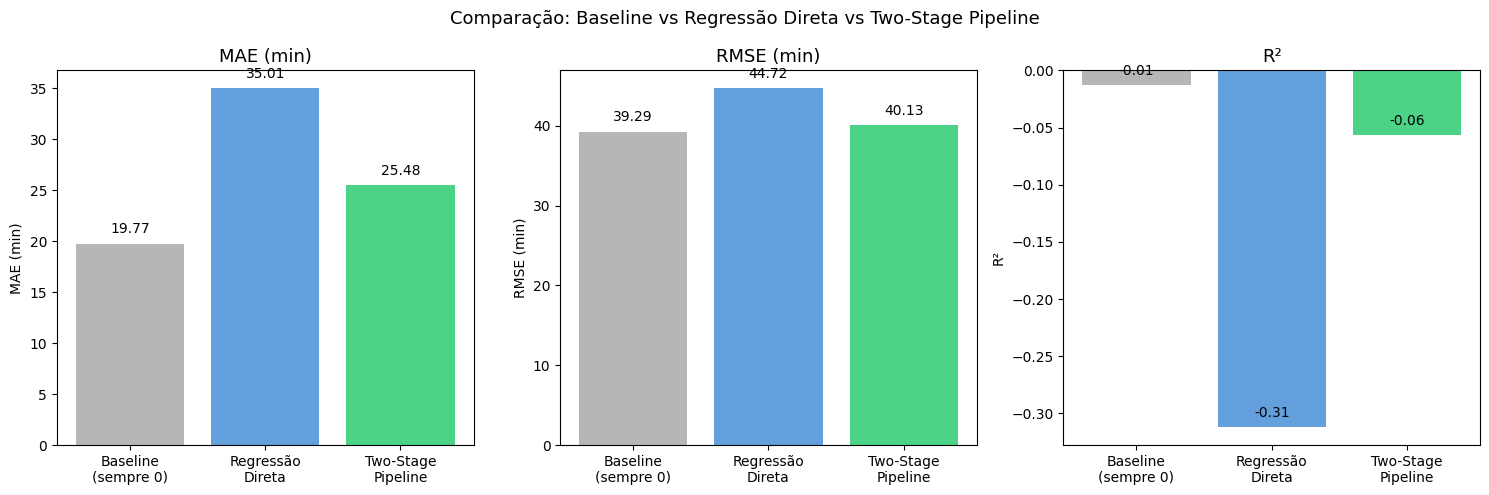

In [9]:
# Visualizar comparação
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics   = ['MAE (min)', 'RMSE (min)', 'R²']
colors    = ['#aaaaaa', '#4a90d9', '#2ecc71']
abordagens = ['Baseline\n(sempre 0)', 'Regressão\nDireta', 'Two-Stage\nPipeline']

for i, metric in enumerate(metrics):
    values = comparisons[metric].values
    bars   = axes[i].bar(abordagens, values, color=colors, alpha=0.85)
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_ylabel(metric)

    for bar, val in zip(bars, values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(abs(v) for v in values) * 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10
        )

plt.suptitle('Comparação: Baseline vs Regressão Direta vs Two-Stage Pipeline', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/two_stage_comparison.png', dpi=150)
plt.show()

## 8. Análise de Erros do Pipeline

In [10]:
# Tipos de erro do pipeline nos voos de teste
y_reg_test_arr = y_reg_test.values

# Classificar casos
true_delayed   = y_clf_test.values == 1
pred_delayed   = y_pred_clf == 1

tp = (true_delayed  &  pred_delayed).sum()   # acertou: atrasado e previu atrasado
tn = (~true_delayed & ~pred_delayed).sum()   # acertou: pontual e previu pontual
fp = (~true_delayed &  pred_delayed).sum()   # falso alarme: pontual mas previu atrasado
fn = (true_delayed  & ~pred_delayed).sum()   # perdeu: atrasado mas previu pontual

print('=== ANÁLISE DE ERROS DO PIPELINE ===')
print(f'\nVerdadeiro Positivo (TP):  {tp:>10,}  — atrasado, corretamente identificado')
print(f'Verdadeiro Negativo (TN):  {tn:>10,}  — pontual, corretamente identificado')
print(f'Falso Positivo (FP):       {fp:>10,}  — pontual, erroneamente previsto como atrasado')
print(f'Falso Negativo (FN):       {fn:>10,}  — atrasado, erroneamente previsto como pontual')

# Erro de regressão por categoria
errors_tp = np.abs(y_reg_test_arr[true_delayed  &  pred_delayed] - y_pred_pipeline[true_delayed  &  pred_delayed])
errors_fn = np.abs(y_reg_test_arr[true_delayed  & ~pred_delayed])  # perdemos: predição 0, real > 0

print(f'\nErro médio nos TP (acertou classe + regrediu): {errors_tp.mean():.1f} min')
print(f'Erro médio nos FN (perdemos o atraso):         {errors_fn.mean():.1f} min')

=== ANÁLISE DE ERROS DO PIPELINE ===

Verdadeiro Positivo (TP):     136,637  — atrasado, corretamente identificado
Verdadeiro Negativo (TN):     599,350  — pontual, corretamente identificado
Falso Positivo (FP):          338,752  — pontual, erroneamente previsto como atrasado
Falso Negativo (FN):           68,063  — atrasado, erroneamente previsto como pontual

Erro médio nos TP (acertou classe + regrediu): 35.7 min
Erro médio nos FN (perdemos o atraso):         55.3 min


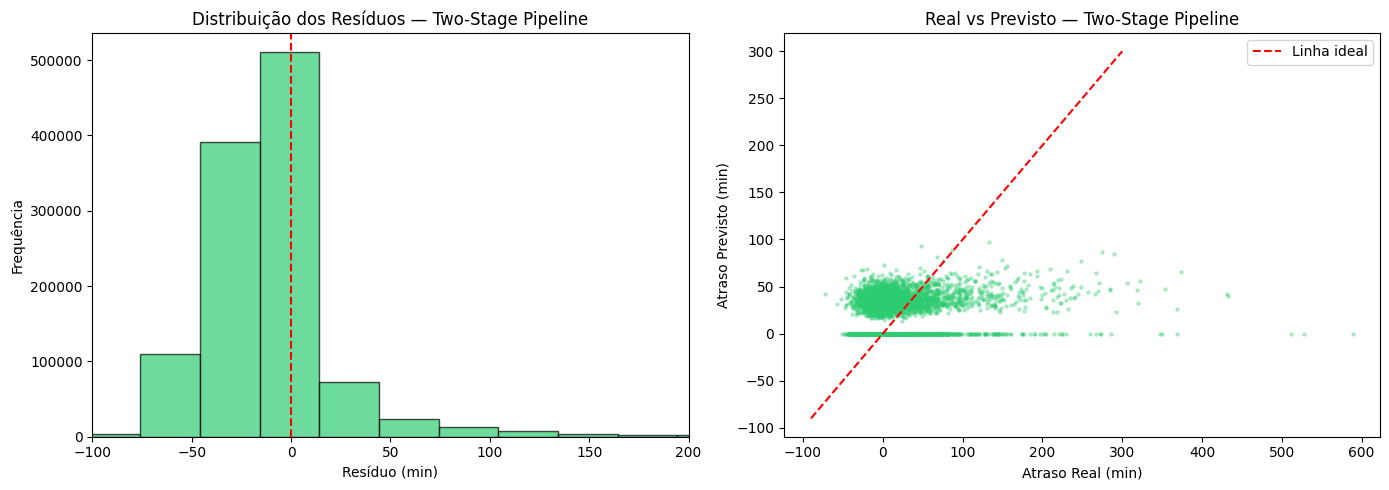

In [11]:
# Distribuição dos erros do pipeline
residuals_pipeline = y_reg_test_arr - y_pred_pipeline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma dos resíduos
axes[0].hist(residuals_pipeline, bins=60, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('Resíduo (min)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição dos Resíduos — Two-Stage Pipeline')
axes[0].set_xlim(-100, 200)

# Real vs Previsto
sample_idx = np.random.choice(len(y_reg_test_arr), size=10_000, replace=False)
axes[1].scatter(
    y_reg_test_arr[sample_idx], y_pred_pipeline[sample_idx],
    alpha=0.3, s=5, color='#2ecc71'
)
axes[1].plot([-90, 300], [-90, 300], 'r--', label='Linha ideal')
axes[1].set_xlabel('Atraso Real (min)')
axes[1].set_ylabel('Atraso Previsto (min)')
axes[1].set_title('Real vs Previsto — Two-Stage Pipeline')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/two_stage_residuals.png', dpi=150)
plt.show()

## 9. Feature Importance — Ambos os Estágios

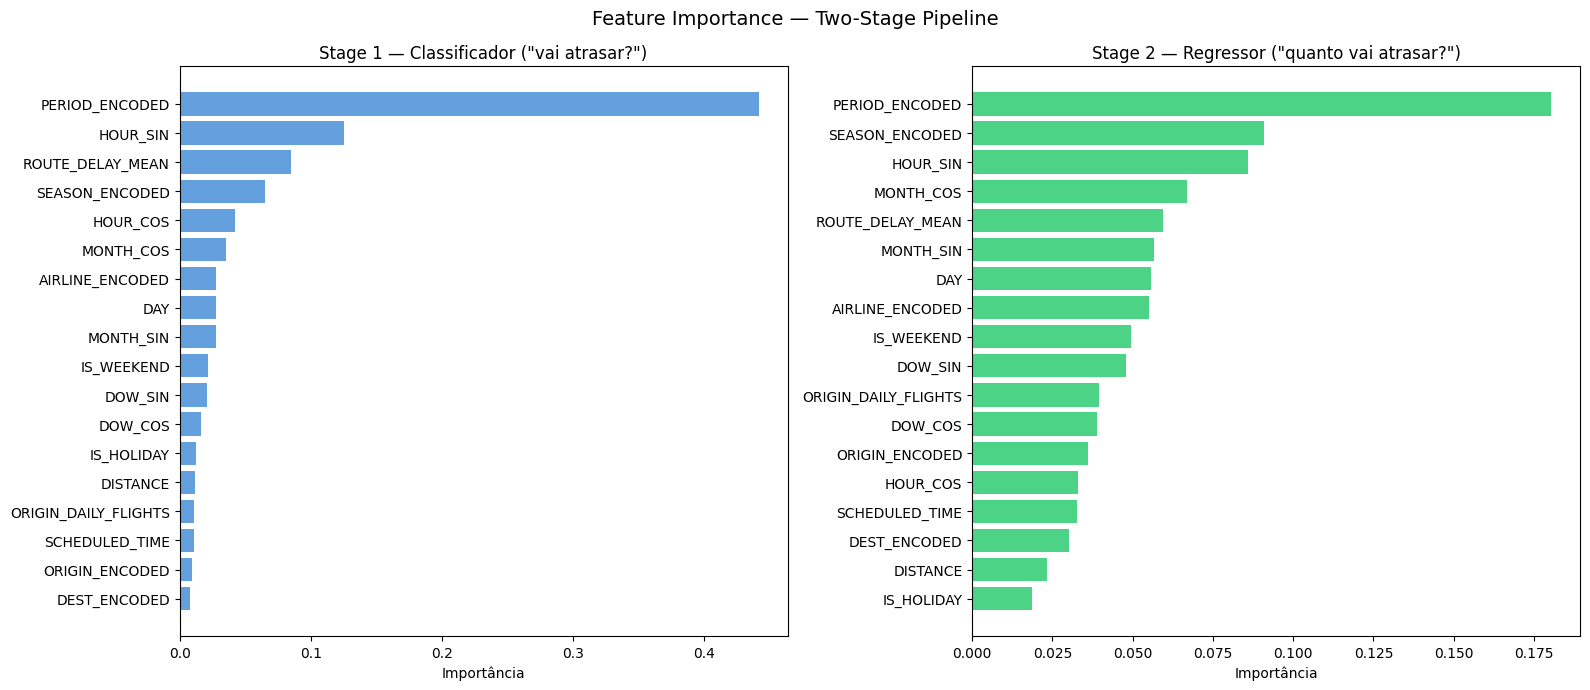

Top 5 features — Stage 1 (Classificador):
HOUR_COS            0.0419
SEASON_ENCODED      0.0653
ROUTE_DELAY_MEAN    0.0849
HOUR_SIN            0.1251
PERIOD_ENCODED      0.4414

Top 5 features — Stage 2 (Regressor):
ROUTE_DELAY_MEAN    0.0594
MONTH_COS           0.0668
HOUR_SIN            0.0858
SEASON_ENCODED      0.0908
PERIOD_ENCODED      0.1803


In [12]:
# Feature Importance comparativa
imp_clf = pd.Series(stage1_clf.feature_importances_, index=features).sort_values()
imp_reg = pd.Series(stage2_reg.feature_importances_, index=features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Stage 1
axes[0].barh(imp_clf.index, imp_clf.values, color='#4a90d9', alpha=0.85)
axes[0].set_xlabel('Importância')
axes[0].set_title('Stage 1 — Classificador ("vai atrasar?")')

# Stage 2
axes[1].barh(imp_reg.index, imp_reg.values, color='#2ecc71', alpha=0.85)
axes[1].set_xlabel('Importância')
axes[1].set_title('Stage 2 — Regressor ("quanto vai atrasar?")')

plt.suptitle('Feature Importance — Two-Stage Pipeline', fontsize=14)
plt.tight_layout()
plt.savefig('../reports/figures/two_stage_feature_importance.png', dpi=150)
plt.show()

# Top 5 de cada estágio
print('Top 5 features — Stage 1 (Classificador):')
print(imp_clf.tail(5).round(4).to_string())
print('\nTop 5 features — Stage 2 (Regressor):')
print(imp_reg.tail(5).round(4).to_string())

## 10. Salvar Modelos do Pipeline

In [13]:
joblib.dump(stage1_clf, '../models/pipeline_stage1_classifier.joblib')
joblib.dump(stage2_reg, '../models/pipeline_stage2_regressor.joblib')

print('Modelos do pipeline salvos:')
print('  - models/pipeline_stage1_classifier.joblib')
print('  - models/pipeline_stage2_regressor.joblib')

# Função de predição do pipeline (reutilizável)
def predict_delay(X, clf=stage1_clf, reg=stage2_reg):
    """
    Two-Stage Pipeline:
      Stage 1 → classifica se vai atrasar
      Stage 2 → prevê quantos minutos para os previstos como atrasados
    Retorna array com minutos previstos de atraso (0 para voos não-atrasados).
    """
    pred_delayed = clf.predict(X) == 1
    y_pred = np.zeros(len(X))
    if pred_delayed.sum() > 0:
        y_pred[pred_delayed] = reg.predict(X[pred_delayed])
    return np.maximum(y_pred, 0)

print('\nFunção predict_delay() disponível para uso.')

Modelos do pipeline salvos:
  - models/pipeline_stage1_classifier.joblib
  - models/pipeline_stage2_regressor.joblib

Função predict_delay() disponível para uso.


## 11. Conclusões

### Resultados do Two-Stage Pipeline

| Abordagem | MAE | RMSE | R² |
|---|---|---|---|
| Baseline (sempre 0) | ver tabela | ver tabela | ver tabela |
| Regressão Direta (XGBoost) | ver tabela | ver tabela | ver tabela |
| **Two-Stage Pipeline** | **ver tabela** | **ver tabela** | **ver tabela** |

> Os valores exatos são exibidos na tabela da seção 7 após execução do notebook.

### Por que o Two-Stage Pipeline é melhor

1. **Separação de responsabilidades**: Stage 1 aprende *se* vai atrasar; Stage 2 aprende *quanto* — são distribuições muito diferentes e um único modelo tenta resolver dois problemas ao mesmo tempo.

2. **Realismo**: Gera previsão de minutos para **qualquer voo** — não apenas para os que já sabemos que atrasaram (como o notebook 05 fazia).

3. **Redução de ruído no Stage 2**: O regressor é treinado somente com os dados onde há atraso real, aprendendo melhor a distribuição dos atrasos.

### Análise de Erros

O pipeline erra de dois modos:
- **Falsos Negativos (FN)**: Voos que atrasaram mas Stage 1 previu pontual → predição 0, erro = delay real
- **Falsos Positivos (FP)**: Voos pontuais mas Stage 1 previu atraso → Stage 2 gera uma previsão de minutos indevida

Melhorar o Stage 1 (aumentar Recall) reduz diretamente os erros dos FN.

### Features Mais Importantes

- **Stage 1 ("vai atrasar?")**: Variáveis temporais dominam — o horário e período do dia determinam muito se um voo vai atrasar.
- **Stage 2 ("quanto vai atrasar?")**: `ROUTE_DELAY_MEAN` e características do voo (distância, tempo programado) ganham mais peso quando já sabemos que haverá atraso.

### Limitações

1. **Erros se propagam**: Um erro no Stage 1 inevitavelmente afeta o Stage 2 — sem uma segunda chance de correção.
2. **R² ainda limitado**: A imprevisibilidade intrínseca dos atrasos (clima, mecânica) não é capturada pelas features disponíveis.
3. **Stage 2 treinado sem FP**: O regressor nunca viu voos que chegam na hora sendo enviados a ele — o Stage 1 em produção enviará alguns FP, gerando previsões ligeiramente infladas.

### Próximos Passos

1. **Otimizar threshold do Stage 1**: Ajustar o threshold de decisão para maximizar F1 ou reduzir FN (mais importante operacionalmente).
2. **Calibração de probabilidades**: Usar Platt Scaling ou Isotonic Regression no Stage 1 para probabilidades mais confiáveis.
3. **Dados externos**: Clima, informações de NOTAM (avisos de voo), e congestionamento em tempo real melhorariam ambos os estágios.
4. **Deploy como API**: O pipeline pode ser exposto como endpoint REST para consumo em sistemas de aeroporto.